### imports

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import requests

### api request

In [ ]:
api_url = "https://api.sportdb.dev/api/flashscore/player/struski-karol/MsnR68Zp/"
response = requests.get(api_url,headers=({"X-API-Key":""}), verify=False)

c:\app\Python311\Lib\site-packages\urllib3\connectionpool.py:1099: InsecureRequestWarning: Unverified HTTPS request is being made to host 'api.sportdb.dev'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(


In [4]:
player = response.json()
player

{'id': 'MsnR68Zp',
 'slug': 'struski-karol',
 'firstName': 'Karol',
 'lastName': 'Struski',
 'teamName': 'Rakow',
 'photo': 'https://static.flashscore.com/res/image/data/x60qHeZg-QZ0VKL9F.png',
 'teamSlug': 'rakow-czestochowa',
 'teamId': 'SQOrbYim',
 'position': '',
 'dob': '2001-01-18',
 'marketValue': '€936k',
 'contractExpires': 'Contract expires: 30.06.2029',
 'playerStatus': 'ACTIVE',
 'countryName': 'Poland',
 'countrySlug': 'poland',
 'countryId': '',
 'careers': {'league': [{'season': '2025-2026',
    'teamName': 'Rakow',
    'teamSlug': 'rakow-czestochowa',
    'teamId': 'SQOrbYim',
    'competitionName': 'Ekstraklasa',
    'competitionSlug': 'ekstraklasa',
    'countrySlug': 'poland',
    'countryId': '',
    'stats': [{'name': 'Player rating', 'value': 6.4},
     {'name': 'Matches Played', 'value': 11},
     {'name': 'Goals Scored', 'value': 0},
     {'name': 'Assists', 'value': 0},
     {'name': 'Yellow Cards', 'value': 3},
     {'name': 'Red Cards', 'value': 1}]},
   {'se

In [5]:
stat_count = 0
rows = []

for competition in player['careers']:
    for season_data in player['careers']['league']:
        print(season_data['season'], competition, season_data['teamSlug'])
        print(10*'=')
        stat_count += 1 
        stats = {stat['name']: stat['value'] for stat in season_data['stats']}
        print(stats)
        row = [
            stats.get("Player rating", 0),
            stats.get("Matches Played", 0),
            stats.get("Goals Scored", 0),
            stats.get("Assists", 0),
            stats.get("Yellow Cards"),
            stats.get('Red Cards'),
            season_data.get('season')
        ]
        rows.append(row)
        print()

player_stats = pd.DataFrame(
    rows,
    columns= [
        'Player rating', 
        'Matches Played', 
        'Goals Scored',
        'Assists', 
        'Yellow Cards', 
        'Red Cards',
        'Season'
    ]
)
    

2025-2026 league rakow-czestochowa
{'Player rating': 6.4, 'Matches Played': 11, 'Goals Scored': 0, 'Assists': 0, 'Yellow Cards': 3, 'Red Cards': 1}

2024-2025 league aris-limassol
{'Player rating': 0, 'Matches Played': 34, 'Goals Scored': 5, 'Assists': None, 'Yellow Cards': 7, 'Red Cards': 0}

2023-2024 league aris-limassol
{'Player rating': 0, 'Matches Played': 23, 'Goals Scored': 2, 'Assists': None, 'Yellow Cards': 2, 'Red Cards': 0}

2022-2023 league aris-limassol
{'Player rating': 0, 'Matches Played': 29, 'Goals Scored': 4, 'Assists': None, 'Yellow Cards': 9, 'Red Cards': 0}

2021-2022 league jagiellonia
{'Player rating': 7, 'Matches Played': 28, 'Goals Scored': 1, 'Assists': 2, 'Yellow Cards': 7, 'Red Cards': 0}

2020-2021 league leczna
{'Player rating': 0, 'Matches Played': 27, 'Goals Scored': 1, 'Assists': None, 'Yellow Cards': 3, 'Red Cards': 0}

2019-2020 league jagiellonia
{'Player rating': 0, 'Matches Played': 2, 'Goals Scored': 0, 'Assists': 0, 'Yellow Cards': 1, 'Red Cards

In [6]:
clean_stats = player_stats.sort_values(by='Season').drop_duplicates()

In [7]:
# AT - all time player stats - across all leagues and competitions
AT_player_stats = clean_stats.sum()
AT_matches = AT_player_stats['Matches Played']
AT_player_rating = clean_stats[clean_stats['Player rating']>0]['Player rating'].mean()
AT_goals_scored_avg = clean_stats['Goals Scored'].sum()/AT_matches
AT_assists_avg = clean_stats['Assists'].sum()/AT_matches
AT_yellows_avg = clean_stats['Yellow Cards'].sum()/AT_matches
AT_reds_avg = clean_stats['Red Cards'].sum()/AT_matches

print(f"All time {player['firstName']} {player['lastName']} Statistics")
print(f"Matches: {AT_player_stats['Matches Played']}")
print(f"Goals: {AT_player_stats['Goals Scored']}")
print(f"Assists: {AT_player_stats['Assists']}")
print(f"Yellows: {AT_player_stats['Yellow Cards']}")
print(f"Reds: {AT_player_stats['Red Cards']}")
print("==== Averages =====")
print(f"Average Player Rating: {AT_player_rating}")
print(f"Goals Scored per match: {AT_goals_scored_avg}")
print(f"Assists per match: {AT_assists_avg}")
print(f"Yellow Cards per match: {AT_yellows_avg}")
print(f"Red Cards per match: {AT_reds_avg}")


All time Karol Struski Statistics
Matches: 154
Goals: 13
Assists: 2.0
Yellows: 32
Reds: 1
==== Averages =====
Average Player Rating: 6.7
Goals Scored per match: 0.08441558441558442
Assists per match: 0.012987012987012988
Yellow Cards per match: 0.2077922077922078
Red Cards per match: 0.006493506493506494


In [8]:
x = clean_stats
x

,Player rating,Matches Played,Goals Scored,Assists,Yellow Cards,Red Cards,Season
13,0.0,2,0,0.0,1,0,2019-2020
12,0.0,27,1,NaN,3,0,2020-2021
18,7.0,28,1,2.0,7,0,2021-2022
24,0.0,29,4,NaN,9,0,2022-2023
9,0.0,23,2,NaN,2,0,2023-2024
22,0.0,34,5,NaN,7,0,2024-2025
14,6.4,11,0,0.0,3,1,2025-2026


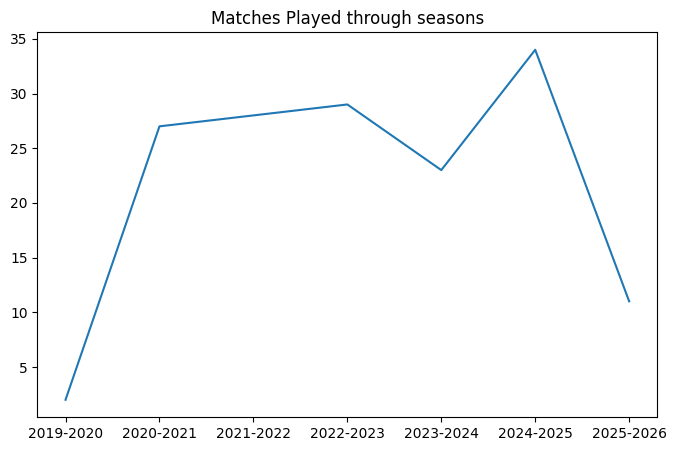

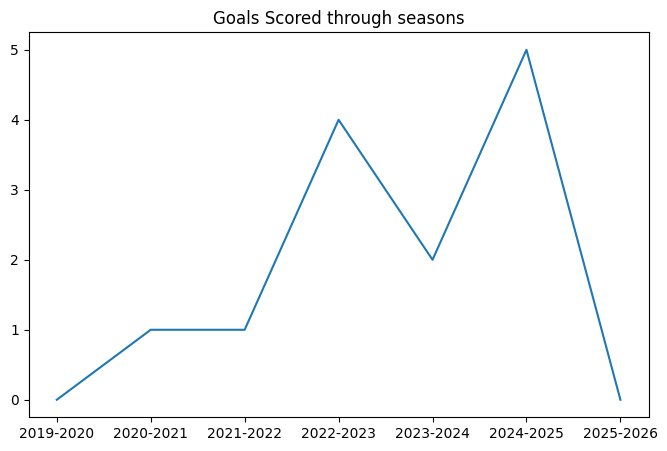

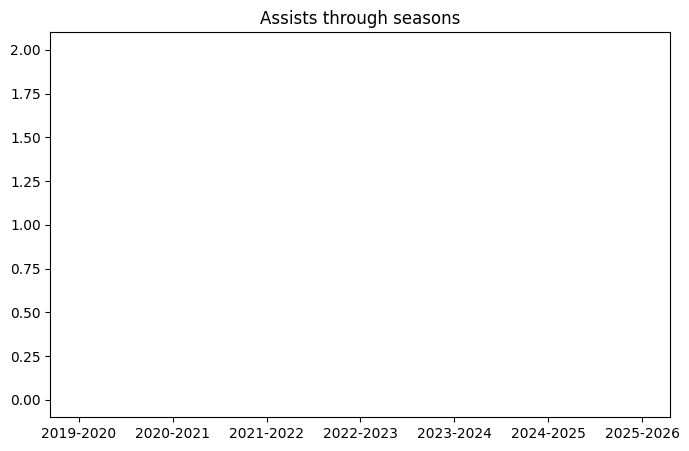

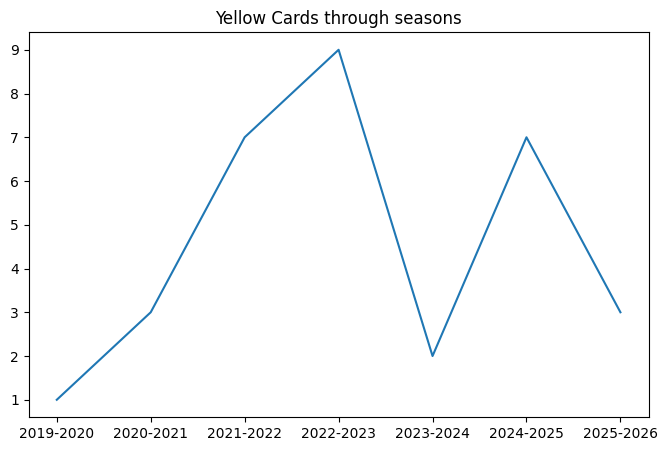

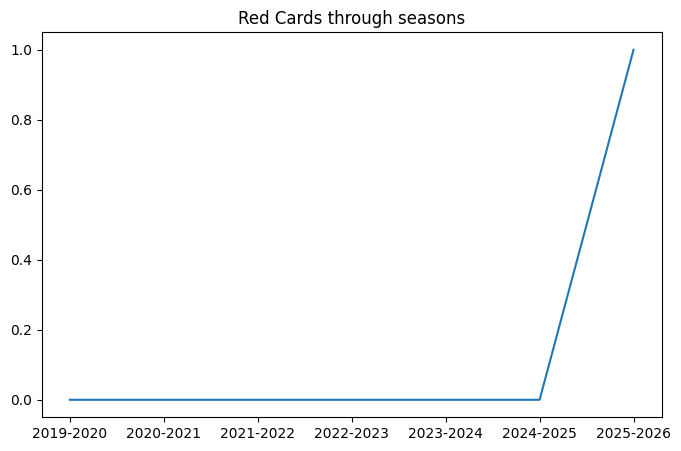

In [9]:
season = clean_stats['Season']
matches = clean_stats['Matches Played']
goals = clean_stats['Goals Scored']
assists = clean_stats['Assists']
yellows = clean_stats['Yellow Cards']
reds = clean_stats['Red Cards']

stats = [matches, goals, assists, yellows, reds]

for stat in stats:    
    plt.figure(figsize=(8,5))
    plt.plot(season,stat)
    plt.title(f"{stat.name} through seasons")